# OF-FF Heuristic in Multi-Switch TSN Network

This notebook demonstrates:

1. Loading a TSN network state from a JSON file.
2. Visualizing the network topology.
3. Displaying the per-link schedule table.
4. Implementing the Older-First First-Fit (OF-FF) heuristic.
5. Applying the heuristic to the network.
6. Visualizing the new schedule after defragmentation.

We will work with multiple switches, multiple ports, and end-to-end streams.


In [72]:
import json
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import Rectangle

In [80]:
# Load network JSON
with open("scenario.json") as f:
    network_data = json.load(f)

# Quick check
print("Nodes:", [n['name'] for n in network_data['nodes']])
print("Streams:", [s['name'] for s in network_data['streams']])

Nodes: ['D', 'F', 'A', 'B', 'C', 'E']
Streams: ['stream-D-to-F', 'stream-D-to-A']


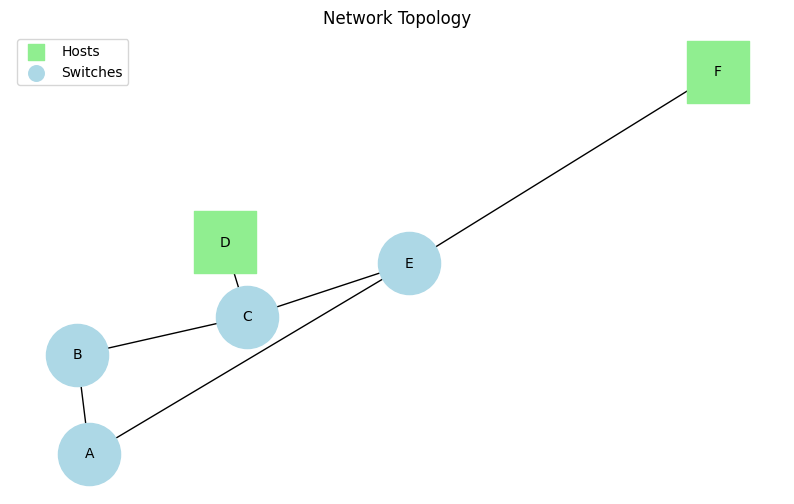

In [81]:

# Load JSON
with open("scenario.json") as f:
    network_data = json.load(f)

G = nx.DiGraph()

# Add nodes
for node in network_data["nodes"]:
    G.add_node(node["name"], type=node["type"])

# Add links
for link in network_data["links"]:
    G.add_edge(
        link["sourceNode"],
        link["destNode"],
        bw=link["linkBw"],
        delay=link["propDelay"]
    )

# Positioning (automatic layout)
pos = nx.spring_layout(G, seed=42)

# Separate hosts and switches
hosts = [n for n, d in G.nodes(data=True) if d["type"] == "host"]
switches = [n for n, d in G.nodes(data=True) if d["type"] == "switch"]

plt.figure(figsize=(10, 6))

# Draw nodes
nx.draw_networkx_nodes(G, pos, nodelist=hosts, node_color="lightgreen",
                       node_shape="s", node_size=2000, label="Hosts")

nx.draw_networkx_nodes(G, pos, nodelist=switches, node_color="lightblue",
                       node_shape="o", node_size=2000, label="Switches")

# Draw edges
nx.draw_networkx_edges(G, pos)

# Labels
nx.draw_networkx_labels(G, pos, font_size=10)

plt.title("Network Topology")
plt.legend(loc='upper left',
           markerscale=0.25)
plt.axis("off")
plt.show()


stream-D-to-F transmits at D.Port1 from 0.0 to 4000.0 ns
stream-D-to-F transmits at C.P1 from 5010.0 to 5010.0 ns
stream-D-to-F transmits at C.P3 from 6010.0 to 10010.0 ns
stream-D-to-F transmits at E.P1 from 11020.0 to 11020.0 ns
stream-D-to-F transmits at E.P3 from 12020.0 to 16020.0 ns
stream-D-to-A transmits at D.Port1 from 0.0 to 4000.0 ns
stream-D-to-A transmits at C.P1 from 5010.0 to 5010.0 ns
stream-D-to-A transmits at C.P2 from 6010.0 to 10010.0 ns
stream-D-to-A transmits at B.P1 from 11020.0 to 11020.0 ns
stream-D-to-A transmits at B.P2 from 12020.0 to 16020.0 ns


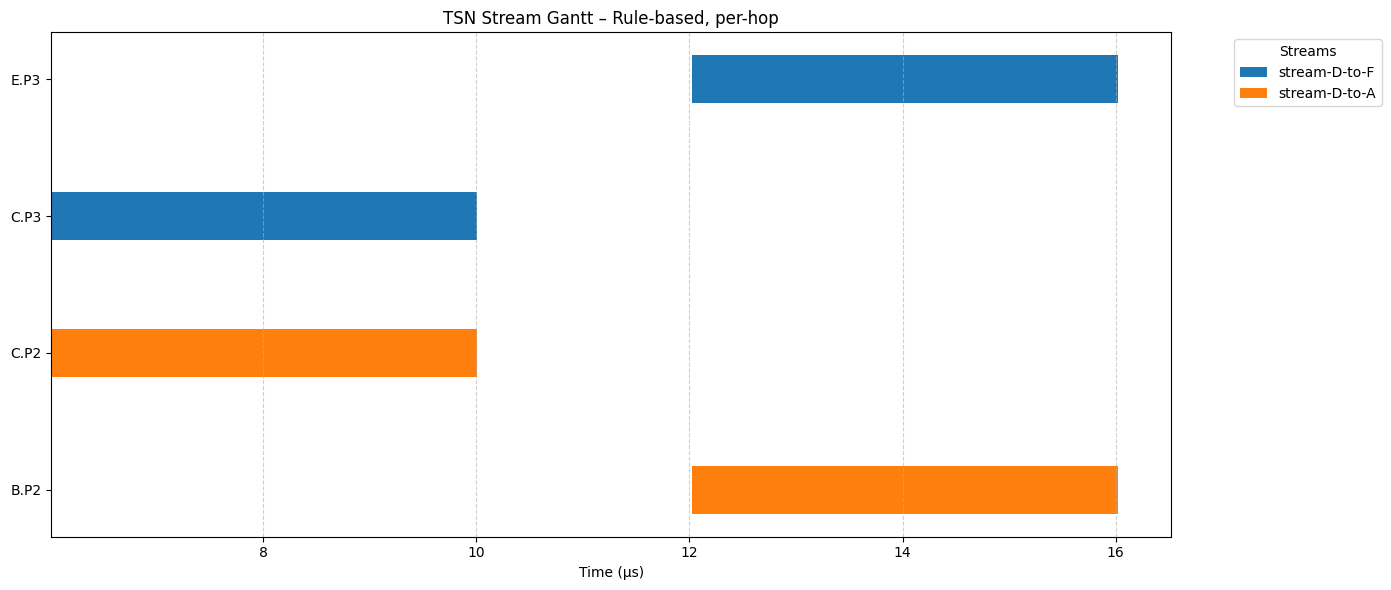

In [95]:
import json
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# -------------------------------
# Load JSON
# -------------------------------
with open("scenario.json") as f:
    data = json.load(f)

# -------------------------------
# Stream color map
# -------------------------------
stream_names = [s["name"] for s in data.get("streams", [])]
palette = list(mcolors.TABLEAU_COLORS.values()) + list(mcolors.CSS4_COLORS.values())
stream_colors = {name: palette[i % len(palette)] for i, name in enumerate(stream_names)}

# -------------------------------
# Build port schedules (only switches with schedules)
# -------------------------------
port_schedule_map = {}
scheduled_ports = []

for node in data["nodes"]:
    if node["type"] != "switch":
        continue
    for port_name, port in node["ports"].items():
        port_key = f"{node['name']}.{port_name}"
        if "schedule" in port:
            scheduled_ports.append({
                "node": node["name"],
                "port": port_name,
                "queueCount": port["queueCount"],
                "cycle": port["scheduleCycle"],
                "firstCycleStart": port.get("firstCycleStart", 0),
                "schedule": port["schedule"]
            })
            port_schedule_map[port_key] = scheduled_ports[-1]

# -------------------------------
# Helpers
# -------------------------------
def get_node_proc_delay(node_name):
    node = next((n for n in data["nodes"] if n["name"] == node_name), None)
    return node.get("procDelay", 0) if node else 0

def get_link(src_node, src_port, dst_node, dst_port):
    return next(
        (l for l in data["links"]
         if l["sourceNode"] == src_node and l["sourcePort"] == src_port
         and l["destNode"] == dst_node and l["destPort"] == dst_port),
        None
    )

def tx_time_ns(max_frame_size_bytes, link_bw_mbps):
    if not link_bw_mbps:
        return 0
    return (max_frame_size_bytes * 8 * 1000) / link_bw_mbps  # ns

def last_queue_open_windows(port_entry):
    windows = []
    last_index = port_entry["queueCount"] - 1
    for slot in port_entry["schedule"]:
        state = slot["state"]
        if last_index < len(state) and state[last_index].lower() == "o":
            windows.append((slot["start"], slot["start"] + slot["duration"]))
    return windows

def next_gate_open_time(port_entry, earliest_start, duration_ns):
    """Return earliest start time for a duration in last queue open windows"""
    cycle = port_entry["cycle"]
    t0 = port_entry.get("firstCycleStart", 0)
    windows = last_queue_open_windows(port_entry)
    if not windows:
        return earliest_start
    t_mod = (earliest_start - t0) % cycle
    cycle_start = earliest_start - t_mod
    # check current cycle
    for w_start, w_end in windows:
        w_abs_start = cycle_start + w_start
        w_abs_end = cycle_start + w_end
        
        # Case 1: Haven't reached the window yet
        if earliest_start <= w_abs_start:
            if w_abs_start + duration_ns <= w_abs_end:
                return w_abs_start
        # Case 2: Already inside the window
        elif earliest_start < w_abs_end:
            if earliest_start + duration_ns <= w_abs_end:
                return earliest_start
    
    # if not fit in current cycle, take first window of next cycle
    return cycle_start + cycle + windows[0][0]

# -------------------------------
# Compute transmissions hop by hop
# -------------------------------
stream_hops = []
log_lines = []

for stream in data.get("streams", []):
    path = stream.get("pathLists", [[]])[0]
    current_time = stream.get("offset", 0)
    max_frame = stream.get("maxFrameSize", 0)

    for i in range(len(path) - 1):
        src, dst = path[i], path[i+1]
        src_node, src_port = src.split(".")
        dst_node, dst_port = dst.split(".")
        link = get_link(src_node, src_port, dst_node, dst_port)
        link_bw = link.get("linkBw", 0) if link else 0
        prop_delay = link.get("propDelay", 0) if link else 0
        proc_delay = get_node_proc_delay(dst_node) if dst_node else 0
        duration_ns = tx_time_ns(max_frame, link_bw)

        port_key = f"{src_node}.{src_port}"
        if port_key in port_schedule_map:
            port_entry = port_schedule_map[port_key]
            start_ns = next_gate_open_time(port_entry, current_time, duration_ns)
        else:
            # no gate, transmit immediately
            start_ns = current_time
        end_ns = start_ns + duration_ns

        stream_hops.append({
            "port_key": port_key,
            "stream": stream["name"],
            "start_ns": start_ns,
            "duration_ns": duration_ns
        })
        log_lines.append(f"{stream['name']} transmits at {port_key} from {start_ns:.1f} to {end_ns:.1f} ns")

        # next hop waits for this hop
        current_time = end_ns + proc_delay + prop_delay

# -------------------------------
# Save logs
# -------------------------------
with open("tsn_stream_log.txt", "w") as f:
    for line in log_lines:
        f.write(line + "\n")
        print(line)

# -------------------------------
# Draw Gantt chart
# -------------------------------
fig, ax = plt.subplots(figsize=(14, 6))
y_positions = range(len(scheduled_ports))
port_index = {f"{p['node']}.{p['port']}": i for i, p in enumerate(scheduled_ports)}
legend_streams = set()

for hop in stream_hops:
    y = port_index.get(hop["port_key"], -1)
    if y == -1:
        continue
    start_us = hop["start_ns"] / 1000
    duration_us = hop["duration_ns"] / 1000
    stream_name = hop["stream"]
    color = stream_colors.get(stream_name, "#999999")
    show_label = stream_name not in legend_streams
    ax.barh(
        y,
        duration_us,
        left=start_us,
        height=0.35,
        color=color,
        label=stream_name if show_label else "_nolegend_"
    )
    legend_streams.add(stream_name)

ax.set_yticks(list(y_positions))
ax.set_yticklabels([f"{p['node']}.{p['port']}" for p in scheduled_ports])
ax.set_xlabel("Time (µs)")
ax.set_title("TSN Stream Gantt – Rule-based, per-hop")
ax.grid(True, axis="x", linestyle="--", alpha=0.6)
ax.legend(title="Streams", bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()


In [52]:
import json

# Base topology
nodes = [
    {"type": "host", "name": "D", "ports": {"Port1": {"name": "Port1", "speed": 1000, "queueCount": 4}}},
    {"type": "host", "name": "F", "ports": {"Port1": {"name": "Port1", "speed": 1000, "queueCount": 4}}},
    {"type": "host", "name": "G", "ports": {"Port1": {"name": "Port1", "speed": 1000, "queueCount": 4}}},
    {
        "type": "switch", "name": "C", "procDelay": 1000,
        "ports": {
            "P1": {"name": "P1", "speed": 1000, "queueCount": 4},
            "P2": {"name": "P2", "speed": 1000, "queueCount": 4, "scheduleCycle": 100000, "firstCycleStart": 0,
                   "schedule": [{"start": 10000, "duration": 15000, "state": "CCCo"},
                                {"start": 25000, "duration": 5000, "state": "CCCC"}]},
            "P3": {"name": "P3", "speed": 1000, "queueCount": 4, "scheduleCycle": 100000, "firstCycleStart": 0,
                   "schedule": [{"start": 0, "duration": 15000, "state": "CoCC"},
                                {"start": 15000, "duration": 15000, "state": "CCoC"}]}
        }
    },
    {
        "type": "switch", "name": "E", "procDelay": 1000,
        "ports": {
            "P1": {"name": "P1", "speed": 1000, "queueCount": 4},
            "P3": {"name": "P3", "speed": 1000, "queueCount": 4, "scheduleCycle": 100000, "firstCycleStart": 0,
                   "schedule": [{"start": 20000, "duration": 15000, "state": "CoCC"},
                                {"start": 35000, "duration": 15000, "state": "CCoC"}]}
        }
    },
    {"type": "switch", "name": "A", "procDelay": 1000, "ports": {"P1": {"name": "P1", "speed": 1000, "queueCount": 4}}}
]

links = [
    {"sourceNode": "D", "sourcePort": "Port1", "destNode": "C", "destPort": "P1", "propDelay": 10, "linkBw": 1000},
    {"sourceNode": "C", "sourcePort": "P3", "destNode": "E", "destPort": "P1", "propDelay": 10, "linkBw": 1000},
    {"sourceNode": "E", "sourcePort": "P3", "destNode": "F", "destPort": "Port1", "propDelay": 10, "linkBw": 1000},
    {"sourceNode": "C", "sourcePort": "P2", "destNode": "A", "destPort": "P1", "propDelay": 10, "linkBw": 1000},
    {"sourceNode": "A", "sourcePort": "P1", "destNode": "G", "destPort": "Port1", "propDelay": 10, "linkBw": 1000}
]

streams = []

# 10 streams of type D→F
for i in range(10):
    streams.append({
        "name": f"stream-D2F-{i+1}",
        "type": "isochronous",
        "interval": 100000,
        "maxFramesPerInterval": 1,
        "maxFrameSize": 500,
        "maxLatency": 300000,
        "offset": i*5000,  # staggered offsets
        "pathLists": [["D.Port1", "C.P1", "C.P3", "E.P1", "E.P3", "F.Port1"]]
    })

# 10 streams of type D→G
for i in range(10):
    streams.append({
        "name": f"stream-D2G-{i+1}",
        "type": "isochronous",
        "interval": 100000,
        "maxFramesPerInterval": 1,
        "maxFrameSize": 500,
        "maxLatency": 300000,
        "offset": i*5000,  # staggered offsets
        "pathLists": [["D.Port1", "C.P1", "C.P2", "A.P1", "G.Port1"]]
    })

scenario = {
    "nodes": nodes,
    "links": links,
    "streams": streams,
    "index": None
}

with open("scenario_many_streams.json", "w") as f:
    json.dump(scenario, f, indent=2)
